---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<br><br>
<h1 align="center">Lec-30: Overview of Langchain and its <b>Models</b> Component</h1>

# Learning agenda of this notebook  

1. Overview of LLM Orchestration Frameworks
2. Core Components of LangChain
    - `Models` Component
    - `Prompts` Component
    - `Chains` Component
    - `Memory` Component
    - `Indexes` Component
    - `Agents` Component
3. Overview of LangChain Models Component
4. Accessing Closed Source Models in LangChain
    - Example 1: Accessing Closed Source Chat Models
5. Accessing Open Source Models in LangChain
    - Example 1: Accessing Open Source HuggingFace Models (HF Inference)
    - Example 2: Accessing Open Source Groq Hosted Models
    - Example 3: Accessing Models Running Locally on Ollama
    - Example 4: Streaming vs Non-Streaming Output
    - Example 5: Input an Image and Get its Description
    - Example 6: Input Text and Generate an Image
6. Hands-On Practice Examples
7. Accessing Closed/Open Source Embedding Models
    - Example 1: Accessing Closed Source Embedding Models
    - Example 2: Accessing Open Source Embedding Models

# <span style='background :lightgreen' >1. Overview of LLM Orchestration Frameworks</span>
- When building applications with large language models (LLMs), we need tools to help us organize and manage how these models work together with other systems. These tools are called "orchestration frameworks" - they help us build structured, reliable applications that use AI effectively.
- Think of these frameworks as toolkits that make it easier to connect AI models with databases, search engines, and other services to create powerful applications.
- LLM orchestration frameworks are software libraries that help developers to:
    - Connect AI models to external data sources
    - Manage conversations and memory in AI applications
    - Build step-by-step workflows for AI tasks
    - Create AI agents that can use different tools
    - Handle complex reasoning and decision-making processes

## a. Comparison of LLM Orchestration Frameworks

| Framework | Icon | Type | Introduced | Description | Key Strengths | Best Use Cases |
|-----------|------|------|------------|-------------|---------------|----------------|
| **[LangChain](https://www.langchain.com/langchain)** | <img src="../images/langchain-color.png" width="60" height="60"> | LLM App Framework | October 2022 | Most widely used open-source framework for building LLM applications with modular, reusable components. Not primarily an agent orchestration engine — that role is complemented by LangGraph. | • Composable pipelines<br>• Chains, tools & RAG<br>• Massive ecosystem of connectors, memory systems & retrievers<br>• Strong community support | • General-purpose AI applications<br>• Chatbots and conversational AI<br>• RAG systems<br>• Learning LLM app foundations<br>• Proof of concept projects |
| **[LlamaIndex](https://www.llamaindex.ai/)** | <img src="../images/llamaindex-color.png" width="60" height="60"> | LLM App Framework | 2022 | Specialized open-source framework for connecting AI models with large amounts of custom data and documents. Optimized for data ingestion, indexing, and retrieval. | • Document indexing & retrieval<br>• Multiple data source connections<br>• Advanced search capabilities<br>• Data processing optimization | • Knowledge base applications<br>• Document search systems<br>• Research assistants<br>• RAG-heavy pipelines |
| **[Haystack](https://haystack.deepset.ai/)** | <img src="https://haystack.deepset.ai/images/logos/haystack.png" width="150" height="90"> | LLM App Framework | 2020 | Production-focused open-source Python framework for building search-based AI applications and pipelines. Enterprise-grade reliability with multiple search backends. | • Production-ready pipelines<br>• Multiple search backends<br>• Multi-modal search support<br>• Enterprise-grade reliability | • Enterprise search engines<br>• Customer support systems<br>• Large-scale information retrieval |
| **[OpenAI Agents SDK](https://github.com/openai/openai-agents-python)** | <img src="../images/agents-sdk-icon.png" width="150" height="90"> | Agentic Framework | March 2025 | Open-source lightweight Python-first framework for building multi-agent workflows with core primitives — Agents, Handoffs, and Guardrails. Tight integration with OpenAI models & Responses API. | • Lightweight & minimal overhead<br>• Native OpenAI model integration<br>• Core primitives: Agents, Handoffs, Guardrails<br>• Rapid prototyping to production | • Projects using OpenAI models as primary LLM<br>• Fast agent prototyping<br>• Production agents with low learning overhead<br>• Simple, fast multi-agent orchestration |
| **[LangGraph](https://www.langchain.com/langgraph)** | <img src="../images/langgraph.png" width="60" height="60"> | Agentic Framework | May 2023 | Open-source graph-orchestration layer built on LangChain for stateful, conditional agent workflows. Each step is a node; edges capture transitions and conditions. Supports long-running agents, streaming, human-in-the-loop, and checkpoints. | • Graph-based state management<br>• Durable execution with checkpoints<br>• Deterministic control with retries & branching<br>• Human-in-the-loop patterns<br>• Used by Uber, LinkedIn, Klarna in production | • Complex multi-step agent workflows<br>• Systems with loops, branching & durable state<br>• Production-grade agentic systems<br>• Workflows requiring human approval |
| **[AutoGen](https://github.com/microsoft/agent-framework)** | <img src="../images/autogen-icon.png" width="200" height="110"> | Agentic Framework | June 2023 | Open-source multi-agent conversation & collaboration framework by Microsoft. Agents converse with each other, call tools, involve humans, and exchange messages in a loop to accomplish tasks. | • Multi-agent conversations<br>• Agent-to-agent collaboration<br>• Tool calling within conversations<br>• Human-in-the-loop support | • Systems where agent dialogue & interaction patterns matter<br>• Sequential discussions<br>• Negotiation bots<br>• Collaborative problem solving |
| **[CrewAI](https://www.crewai.com/)** | <img src="../images/crewai-color.png" width="60" height="60"> | Agentic Framework | Early 2024 | Open-source multi-agent orchestration framework based on the crew/team metaphor. Agents are assigned roles, goals, and backstories and work collaboratively to complete tasks. | • Role-based agent design<br>• Intuitive multi-agent delegation<br>• Task coordination & automation<br>• Human oversight capabilities | • Projects benefiting from role-based collaboration<br>• Content creation workflows<br>• Complex task automation<br>• Collaborative AI systems |
| **[n8n](https://n8n.io/)** | <img src="../images/n8n.png" width="60" height="60"> | Workflow Automation | 2019 | Visual workflow automation platform combining AI capabilities with business process automation. Low-code/no-code approach with 500+ integrations and self-hosted or cloud deployment. | • 500+ app integrations built-in<br>• Visual drag-and-drop interface<br>• Self-hosted or cloud deployment<br>• Real-time streaming & dynamic model selection<br>• Cost-effective pricing model | • AI workflow automation for non-developers<br>• Business process automation (ETL, marketing, DevOps)<br>• Autonomous AI agents with controllable autonomy<br>• Enterprise integration workflows |


## b. Framework Comparison Matrix

| **Capability** | **LangChain** | **LlamaIndex** | **Haystack** | **LangGraph** | **OpenAI Agents SDK** | **AutoGen** | **CrewAI** | **n8n** |
|----------------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **RAG Support** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐ |
| **Tool Integration** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **External Systems** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ |
| **State Management** | ⭐⭐ | ⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Agent Capabilities** | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Multi-Agent Support** | ⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Learning Curve** | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Visual Interface** | ⭐ | ⭐ | ⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐ | ⭐⭐⭐⭐⭐ |
| **Debugging & Tracing** | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐ |

# <span style='background :lightgreen' >2. Core Components of [LangChain](https://github.com/langchain-ai/langchain)</span>


<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">LangChain is an open source framework that provides us with a set of tools and abstractions that make it easier for us to create complex LLM-powered applications.</h3>

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Langchain components can be chained together to create sophisticated AI applications like chatbots, question-answering systems, and intelligent agents.</h3>


| Component | Description | Key Benefit |
|-----------|--------------|-------------|
| **Models** | LangChain's "universal remote control" for AI—one interface to rule them all, freeing developers from vendor-specific complexity and enabling true AI provider independence. | Write once, use with any AI model |
| **Prompts** | Reusable, parameterized templates that standardize how you communicate with AI models. | Consistent messaging with easy updates | 
| **Memory** | LangChain Memory enables AI models to maintain context across multiple interactions in a conversation. Without memory, each interaction is independent - the model has no knowledge of previous exchanges. | Natural, flowing conversations |
| **Chains** | LangChain’s “AI Assembly Lines” — they connect multiple models, prompts, or tools together into a logical flow of reasoning, automating complex multi-step tasks with simplicity and consistency. | Transform complex tasks into simple sequences | 
| **Indexes** | Indexes are LangChain's smart knowledge management systems that convert your raw documents (PDFs, websites, databases) into searchable libraries where AI models can quickly find and retrieve only the most relevant information w/o exceeding context limits. | Fast retrieval, reduced API costs | 
| **Agents** | LangChain Agents are the “decision-making brains” of your AI system — they enable models to reason, plan, and dynamically decide which tools to use and what actions to take in order to achieve a user’s goal.| Autonomous problem-solving without manual programming |

# <span style='background :lightgreen' >3. Overview of LangChain **Models** Component</span>

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Models are LangChain's "universal remote control" for AI—one interface to rule them all, freeing developers from vendor-specific complexity and enabling true AI provider independence.</h3>

<img src="../images/Model.png" alt="LangChain Models" 
     style="float: right; width: 700px; margin-left: 10px; border-radius: 8px;">

- Models are the core interfaces in LangChain that connect your application to AI providers (OpenAI, Anthropic, Groq, Google, etc.).
- They include both Language Models (LLMs) that generate text, images, or audio responses from multi-modal inputs, and Embedding Models that convert text into numerical vector representations for similarity search and retrieval.
- LangChain provides a unified abstraction layer that transforms the fragmented landscape of multiple AI provider APIs—each with different authentication methods, function calls, and response formats—into a single, consistent interface.
- This standardization enables developers to write code once and seamlessly switch between any AI provider by changing just two lines, allowing teams to focus on building intelligent applications rather than wrestling with API complexities, vendor lock-in, or integration maintenance.

### [**LangChain LLM Models**](https://python.langchain.com/docs/integrations/llms/)
- General purpose models that are used for raw text generation. They take a string (plain text) as input and returns a string (plain text) as output. These are traditionally older models and are not much used now. The names of these models typically include 'LLM' as a suffix in their name typically refer to the base Large Language Models.

### [**LangChain Chat Models**](https://docs.langchain.com/oss/python/integrations/chat)
- Chat models are LLMs that are specialized for conversational tasks. They take a sequence of messages as input and return chat messages as output. These are traditionally newer models and are preferred for designing apps like conversational chatbots, coding assistants, and agents. The names of these models typically include 'Chat' as a suffix in their name typically refer to the chat Large Language Models.

### [**LangChain Embedding Models**](https://docs.langchain.com/oss/python/integrations/text_embedding)
- Embedding models transform raw text—such as a sentence, paragraph, or tweet—into a fixed-length vector of numbers that capture semantic meaning. These vectors allow machines to compare and search text based on meaning rather than exact word matches.
- **Closed-Source Examples:** OpenAI `text-embedding-3-large`, Cohere `embed-english-v3`, Google `textembedding-gecko`
- **Open-Source Examples:** `sentence-transformers/all-MiniLM-L6-v2`, `bge-large-en`, `e5-base-v2`


| **Aspect** | **Base Models (Foundation/Completion)** | **Chat Models (Instruction-Tuned)** |
|------------|----------------------------------------|-------------------------------------|
| **Primary Purpose** | Text completion and generation based on patterns learned during pre-training | Following instructions, engaging in dialogue, and completing specific tasks |
| **Training Process** | Pre-trained on massive text corpora using self-supervised learning (next-token prediction) | Base model + supervised fine-tuning (SFT) on instruction-response pairs + reinforcement learning from human feedback (RLHF) |
| **Training Data** | Raw internet text, books, articles, code repositories, and web pages (unsupervised) | Curated instruction-following datasets, human-annotated conversations, safety guidelines, and preference-ranked responses |
| **Input Format** | Single text prompt or partial text to complete | Structured conversation with roles (system, user, assistant) and message history |
| **Output Behavior** | Completes the text based on statistical patterns; may continue in unexpected directions | Responds directly to user queries; follows instructions; maintains helpful, harmless, honest responses |
| **Memory & Context** | No built-in conversation memory; each prompt is independent | Maintains conversation context through message history; can reference previous exchanges |
| **Role Awareness** | No concept of roles or personas; simply continues text | Understands and maintains assistant role; respects system prompts and user instructions |
| **Safety & Alignment** | Minimal safety guardrails; may generate problematic content | Enhanced safety through RLHF; refuses harmful requests; aligned with human values |
| **Prompt Sensitivity** | Highly sensitive to prompt format and phrasing | More robust to various phrasings; understands intent better |
| **Response Style** | Continues in the style of the prompt; unpredictable formatting | Consistent, structured responses; formatted for readability |
| **Example: Closed Source** | • GPT-3 (davinci, curie, babbage)<br>• GPT-3.5 Turbo Instruct<br>• Claude 2.1 (legacy)<br>• PaLM 2 (base) | • GPT-4o, GPT-4o-mini<br>• Claude 3.5 Sonnet, Claude 3 Haiku<br>• Gemini 2.0 Flash, Gemini 1.5 Pro<br>• Command R+ (Cohere) |
| **Example: Open Source** | • LLaMA 2 Base<br>• Mistral 7B Base<br>• Falcon 40B | • LLaMA 2 Chat, LLaMA 3 Instruct<br>• Mistral 7B Instruct<br>• OpenChat |
| **Use Cases** | • Custom fine-tuning for specific domains<br>• Research and experimentation<br>• Text generation for creative writing<br>• Code completion (raw autocomplete)<br>• Few-shot learning experiments | • Chatbots and virtual assistants<br>• Question answering systems<br>• Task completion (summarization, translation)<br>• Code generation with instructions<br>• Customer support<br>• Educational tutoring |


### The Core Problem: API Fragmentation
- **Challenge:** Every AI provider has different APIs, authentication methods, and response formats.
- **Real-world Impact:**
    - OpenAI uses one syntax → Anthropic uses another → Google uses yet another
    - Switching providers means rewriting entire codebases
    - Managing multiple API patterns creates maintenance nightmares
    - Teams waste time on integration code instead of building features



| **Aspect** | **❌ Direct SDK / Provider APIs** | **✅ Using LangChain** |
|---|---|---|
| **1️⃣ Imports** | Each provider has its own library:<br>`from openai import OpenAI`<br>`from anthropic import Anthropic`<br>`import google.generativeai as genai`<br>`import ollama` | One consistent pattern per provider, all from LangChain:<br>`from langchain_openai import ChatOpenAI`<br>`from langchain_anthropic import ChatAnthropic`<br>`from langchain_google_genai import ChatGoogleGenerativeAI`<br>`from langchain_ollama import ChatOllama` |
| **2️⃣ Authentication** | Each provider has its own style:<br>OpenAI → `OpenAI(api_key="sk-...")`<br>Anthropic → `Anthropic(api_key="sk-ant-...")`<br>Gemini → `genai.configure(api_key="AIza...")`<br>Ollama → No API key (runs locally) | LangChain auto-reads from environment variables — just set them once:<br>`OPENAI_API_KEY`<br>`ANTHROPIC_API_KEY`<br>`GOOGLE_API_KEY`<br>Ollama → No API key needed (runs locally) |
| **3️⃣ Model Initialization** | Each provider uses a different pattern:<br>**OpenAI:** `client = OpenAI()`<br>**Anthropic:** `client = Anthropic()`<br>**Gemini:** `model = genai.GenerativeModel("gemini-1.5-flash")`<br>**Ollama:** No client object — model name passed at call time | Same pattern for all providers:<br>**OpenAI:** `ChatOpenAI(model="gpt-4o-mini", temperature=0.7)`<br>**Anthropic:** `ChatAnthropic(model="claude-3-haiku-20240307")`<br>**Gemini:** `ChatGoogleGenerativeAI(model="gemini-1.5-flash")`<br>**Ollama:** `ChatOllama(model="llama3")` |
| **4️⃣ Calling the Model** | Each provider has a different method name and structure:<br>OpenAI → `client.chat.completions.create(...)`<br>Anthropic → `client.messages.create(...)`<br>Gemini → `model.generate_content(question)`<br>Ollama → `ollama.chat(model="llama3", ...)` | One unified method for ALL providers:<br>`result = model.invoke(question)` |
| **5️⃣ Extracting the Response** | Each provider returns a different response structure — you have to learn each one:<br>**OpenAI:** `response.choices[0].message.content`<br>**Anthropic:** `response.content[0].text`<br>**Gemini:** `response.text`<br>**Ollama:** `response["message"]["content"]` | Same for ALL providers — no guessing:<br>`result.content` |
| **6️⃣ Switching Providers** | Requires rewriting imports, authentication, the model call, and response parsing — essentially starting over | Just swap the model class (e.g. `ChatOpenAI` → `ChatAnthropic`). Everything else stays the same |
| **7️⃣ Multi-Step Workflows** | You must manually build chaining, conversation memory, agents, and tool use from scratch | LangChain provides built-in support for chains, memory, agents, tools, and RAG pipelines |
| **8️⃣ Code Consistency** | Different syntax and response schemas across providers — hard to maintain as projects grow | Identical patterns everywhere — easier to read, debug, and scale |


# <span style='background :lightgreen' >4. Accessing Closed Source Models in LangChain</span>

## Example 1: Accessing Closed Source Chat Models

In [1]:
import os                                                  # Access environment variables (e.g. os.getenv("API_KEY"))
from dotenv import load_dotenv                             # Load API keys from a .env file into environment variables
from langchain_openai import ChatOpenAI                    # LangChain wrapper for OpenAI models (e.g. GPT-4o)
from langchain_anthropic import ChatAnthropic              # LangChain wrapper for Anthropic models (e.g. Claude)
from langchain_google_genai import ChatGoogleGenerativeAI  # LangChain wrapper for Google models (e.g. Gemini)
from langchain.chat_models import init_chat_model          # Universal initializer to load any chat model by name & provider


# load_dotenv() loads keys from the .env file into environment variables. LangChain then auto-reads those variables (e.g. OPENAI_API_KEY) in the background,
# Since there is no need to pass keys manually like ChatOpenAI(openai_api_key="sk-..."), therefore, no need for `openai_api_key = os.getenv('OPENAI_API_KEY')`
load_dotenv('../keys/.env', override=True)

openai_api_key = os.getenv("OPENAI_API_KEY")  # optional as LangChain auto-read API key
anthropic_api_key = os.getenv('ANTHROPIC_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')

# Model initialization
openai_model    = ChatOpenAI(model="gpt-4o-mini",                       api_key=openai_api_key,    temperature=0.7, max_completion_tokens=256)   
anthropic_model = ChatAnthropic(model="claude-haiku-4-5-20251001",        api_key=anthropic_api_key, temperature=0.7, max_tokens=256) 
gemini_model    = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", api_key=google_api_key,    temperature=0.7, max_output_tokens=256) 

# Invoke the models
openai_response = openai_model.invoke("Tell me a joke about Generative AI")
anthropic_response = anthropic_model.invoke("Tell me a joke about Generative AI")
gemini_response = gemini_model.invoke("Tell me a joke about Generative AI")

# Print the outputs
print("\033[1m=== OpenAI GPT Response ===\033[0m")
print(openai_response.content)
print("\033[1m=== Anthropic Claude Response ===\033[0m")
print(anthropic_response.content)
print("\033[1m=== Google Gemini Response ===\033[0m")
print(gemini_response.content)

=== OpenAI GPT Response ===
Why did the generative AI break up with its dataset?

Because it couldn’t handle the commitment issues!
=== Anthropic Claude Response ===
# Why did the AI go to therapy?

Because it had too many issues to *generate* a solution on its own!

---

Or here's another one:

**Me:** "AI, tell me a joke."

**AI:** "I would, but I'm afraid it might just be a remix of something I've already seen in my training data."

**Me:** "That's not funny."

**AI:** "Exactly."
=== Google Gemini Response ===
Why did the Generative AI break up with the chatbot?

Because it felt like the chatbot was just repeating itself, and the AI was looking for a more *original* connection!


# <span style='background :lightgreen' >5. Accessing Open Source Models in LangChain</span>
- One option is to install `langchain-groq`  or `langchain_Huggingface` package along with all of its dependencies.
- Other option is to use the `ChatOpenAI` by specifying the custom `base_url` and the appropriate API key


| Feature           | **Groq (via OpenAI-compatible endpoint)**                                                    | **Hugging Face Router (via OpenAI-compatible endpoint)**                         | **Ollama (Local OpenAI-compatible endpoint)**                                  |
| ----------------- | -------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------- | ------------------------------------------------------------------------------ |
| **API URL**       | `https://api.groq.com/openai/v1`                                                             | `https://router.huggingface.co/v1`                                               | `http://localhost:11434/v1`                                                    |
| **Backend**       | Groq LPU (Language Processing Unit) infrastructure optimized for ultra-low latency inference | Hugging Face Inference Router that routes requests to community or hosted models | Local Ollama runtime serving models directly from your machine’s CPU/GPU       |
| **Model Source**  | Groq-hosted variants of open models (e.g. LLaMA 3.3, Mixtral, Gemma, etc.)                   | Hugging Face-hosted open models from the Hub                                     | Locally downloaded and managed open models (e.g. LLaMA 3.2, DeepSeek, Mistral) |
| **Compatibility** | Fully **OpenAI API-compatible**                                                              | **OpenAI-compatible** via Hugging Face’s “inference router” API                  | Fully **OpenAI API-compatible** for local inference                            |
| **Latency**       | Very fast (sub-100 ms typical)                                                               | Depends on backend model and queue time                                          | Low latency (depends on local hardware and model size)                         |
| **API Key**       | Requires `groq_api_key`                                                                      | Requires `hf_api_key`                                                            | No API key required (local access only)                                        |
| **Deployment**    | Cloud-hosted, always online                                                                  | Cloud-hosted via Hugging Face                                                    | Runs locally via `ollama serve`                                                |
| **Best Use Case** | Ultra-fast inference of large models via Groq hardware                                       | Accessing a wide variety of open-source models easily                            | Offline experimentation, privacy-sensitive or edge deployments                 |


## Example 1: Accessing Open Source HuggingFace Models (HF Inference)

In [2]:
import os                                          # Access environment variables (e.g. os.getenv("API_KEY"))
from dotenv import load_dotenv                     # Load API keys from a .env file into environment variables
from langchain_openai import ChatOpenAI            # LangChain wrapper used for OpenAI-compatible APIs (e.g. HuggingFace Router)

# load_dotenv() loads keys from the .env file into environment variables.
# Unlike closed-source models, HuggingFace does not have a LangChain auto-read variable,
# so we manually read the key using os.getenv() and pass it explicitly via api_key=
load_dotenv('../keys/.env', override=True)
hf_api_key = os.getenv("HF_TOKEN")  # Manually read since LangChain doesn't auto-read HF tokens

# Model initialization
# Note: All three models use ChatOpenAI because HuggingFace Router exposes an OpenAI-compatible API endpoint.
# We point base_url to the HuggingFace Router and pass the HF token as the api_key.
llama_3_1_model      = ChatOpenAI(model="meta-llama/Llama-3.1-8B-Instruct",           api_key=hf_api_key, base_url="https://router.huggingface.co/v1", temperature=0.7, max_tokens=512)
llama_3_3_model      = ChatOpenAI(model="meta-llama/Llama-3.3-70B-Instruct",          api_key=hf_api_key, base_url="https://router.huggingface.co/v1", temperature=0.7, max_tokens=512)
llama_4_scout_model  = ChatOpenAI(model="meta-llama/Llama-4-Scout-17B-16E-Instruct",  api_key=hf_api_key, base_url="https://router.huggingface.co/v1", temperature=0.7, max_tokens=512)
gpt_oss_20b_model    = ChatOpenAI(model="openai/gpt-oss-20b",                         api_key=hf_api_key, base_url="https://router.huggingface.co/v1", temperature=0.7, max_tokens=512)

# Invoke the models
llama_3_1_response     = llama_3_1_model.invoke("Tell me a joke about Generative AI")
llama_3_3_response     = llama_3_3_model.invoke("Tell me a joke about Generative AI")
llama_4_scout_response = llama_4_scout_model.invoke("Tell me a joke about Generative AI")
gpt_oss_20b_response   = gpt_oss_20b_model.invoke("Tell me a joke about Generative AI")

# Print the outputs
print("\033[1m=== Meta LLaMA 3.1 8B Instruct Response ===\033[0m")
print(llama_3_1_response.content)
print("\033[1m=== Meta LLaMA 3-3 70B Instruct Response ===\033[0m")
print(llama_3_3_response.content)
print("\033[1m=== Meta LLaMA 4 Scout 17B 16E Instruct Response ===\033[0m")
print(llama_4_scout_response.content)
print("\033[1m=== GPT OSS 20B Response ===\033[0m")
print(gpt_oss_20b_response.content)

=== Meta LLaMA 3.1 8B Instruct Response ===
Why did the Generative AI go to therapy?

Because it was struggling to come up with original content, and it was feeling a little "generated" under the pressure.
=== Meta LLaMA 3-3 70B Instruct Response ===
Why did the Generative AI model go to therapy?

Because it was struggling to generate a sense of self and was feeling a little "trained" to please everyone else.
=== Meta LLaMA 4 Scout 17B 16E Instruct Response ===
Here's one:

Why did the Generative AI model go to therapy?

Because it was struggling to generate meaning in its life, and its responses were always latent with anxiety!

(Sorry, I know it's a bit of a "generated" groaner, but I hope it made you laugh!)
=== GPT OSS 20B Response ===
Why did the generative AI break up with its dataset?

Because it kept saying, “I’m sorry, but I can’t commit to any one file!”


## Example 2: Accessing Open Source Groq Hosted Models

In [3]:
import os                                          # Access environment variables (e.g. os.getenv("API_KEY"))
from dotenv import load_dotenv                     # Load API keys from a .env file into environment variables
from langchain_openai import ChatOpenAI            # LangChain wrapper used for OpenAI-compatible APIs (e.g. HuggingFace Router)

# load_dotenv() loads keys from the .env file into environment variables.
# Unlike closed-source models, HuggingFace does not have a LangChain auto-read variable,
# so we manually read the key using os.getenv() and pass it explicitly via api_key=
load_dotenv('../keys/.env', override=True)
groq_api_key = os.getenv("GROQ_API_KEY")  # Manually read since LangChain doesn't auto-read HF tokens

# Model initialization
# Note: All three models use ChatOpenAI because HuggingFace Router exposes an OpenAI-compatible API endpoint.
# We point base_url to the HuggingFace Router and pass the HF token as the api_key.
gpt_oss_model         = ChatOpenAI(model="openai/gpt-oss-120b",    api_key=groq_api_key, base_url="https://api.groq.com/openai/v1", temperature=0.7, max_tokens=512)
llama_instant_model   = ChatOpenAI(model="llama-3.1-8b-instant",   api_key=groq_api_key, base_url="https://api.groq.com/openai/v1", temperature=0.7, max_tokens=512)
llama_versatile_model = ChatOpenAI(model="llama-3.3-70b-versatile",api_key=groq_api_key, base_url="https://api.groq.com/openai/v1", temperature=0.7, max_tokens=512)

# Invoke the models
gpt_oss_response         = gpt_oss_model.invoke("Tell me a joke about Generative AI")
llama_instant_response   = llama_instant_model.invoke("Tell me a joke about Generative AI")
llama_versatile_response = llama_versatile_model.invoke("Tell me a joke about Generative AI")

# Print the outputs
print("\033[1m=== openai/gpt-oss-120b Response ===\033[0m")
print(gpt_oss_response.content)
print("\033[1m=== llama-3.1-8b-instant Response ===\033[0m")
print(llama_instant_response.content)
print("\033[1m=== llama-3.3-70b-versatile Response ===\033[0m")
print(llama_versatile_response.content)

=== openai/gpt-oss-120b Response ===
Why did the generative AI break up with its dataset?

Because every time it tried to *commit* to a relationship, the data kept *over‑fitting* and saying, “It’s not you, it’s the model!” 😄
=== llama-3.1-8b-instant Response ===
Why did the Generative AI go to therapy?

Because it was struggling to generate a stable personality.
=== llama-3.3-70b-versatile Response ===
Why did the Generative AI model go to therapy?

Because it was struggling to generate a sense of self, and its responses were always a little "trained" and not entirely original. But in the end, it just needed to re-boot its thinking and learn to laugh at its own beta mistakes.


## Example 3: Accessing Models Running Locally on Ollama

In [4]:
#Before Running ensure Ollama is running: !ollama serve
!ollama list  # list all the models you have on your machine

]11;?\NAME                        ID              SIZE      MODIFIED      
tinyllama-ft-peft:latest    c910d9ca7c69    1.2 GB    4 weeks ago      
qwen3.5:cloud               a7bf6f7891c3    -         7 weeks ago      
qwen3-vl:235b-cloud         86b3322ec200    -         7 weeks ago      
qwen3.5:397b-cloud          a7bf6f7891c3    -         7 weeks ago      
minimax-m2.5:cloud          c0d5751c800f    -         2 months ago     
mygemma:latest              a631de1ab12d    1.1 GB    4 months ago     
deepseek-v3.1:671b-cloud    d3749919e45f    -         4 months ago     
gpt-oss:20b-cloud           875e8e3a629a    -         4 months ago     
gpt-oss:120b-cloud          569662207105    -         4 months ago     
qwen3-coder:480b-cloud      e30e45586389    -         4 months ago     
nomic-embed-text:latest     0a109f422b47    274 MB    4 months ago     
tinyllama:latest            2644915ede35    637 MB    4 months ago     
deepseek-r1:1.5b            e0979632db5a    1.1 GB    10 mo

In [5]:
from langchain_openai import ChatOpenAI        # LangChain wrapper used for OpenAI-compatible APIs (e.g. HuggingFace Router)


# Model initialization
# Note: All three models use ChatOpenAI because Ollama exposes an OpenAI-compatible API endpoint at the localhost at port 11434.
deepseek_model   = ChatOpenAI(model="deepseek-r1:1.5b", api_key="abc", base_url="http://localhost:11434/v1", temperature=0.7, max_tokens=512)
llama_1b_model   = ChatOpenAI(model="llama3.2:1b",      api_key="abc", base_url="http://localhost:11434/v1", temperature=0.7, max_tokens=512)
llama_3b_model   = ChatOpenAI(model="llama3.2:latest",  api_key="abc", base_url="http://localhost:11434/v1", temperature=0.7, max_tokens=512)

# Invoke the models
deepseek_response = deepseek_model.invoke("Tell me a joke about Generative AI")
llama_1b_response = llama_1b_model.invoke("Tell me a joke about Generative AI")
llama_3b_response = llama_3b_model.invoke("Tell me a joke about Generative AI")

# Print the outputs
print("\033[1m=== deepseek-r1:1.5b Response ===\033[0m")
print(deepseek_response.content)
print("\033[1m=== llama3.2:1b Response ===\033[0m")
print(llama_1b_response.content)
print("\033[1m=== llama3.2:latest Response ===\033[0m")
print(llama_3b_response.content)

=== deepseek-r1:1.5b Response ===
**Joke:** "Why did the AI generate a funny image? Because it had no idea what a human being was!"
=== llama3.2:1b Response ===
Here's one:

Why did the Generative AI go to therapy?

Because it was struggling to generate feelings, and its outputs were always generating anxiety!
=== llama3.2:latest Response ===
Why did the generative AI go to therapy?

Because it was struggling to generate meaningful relationships and kept generating false hopes!


## Example 4: Streaming vs Non-Streaming Output

In [6]:
import os                                          # Access environment variables (e.g. os.getenv("API_KEY"))
from dotenv import load_dotenv                     # Load API keys from a .env file into environment variables
from langchain_openai import ChatOpenAI            # LangChain wrapper used for OpenAI-compatible APIs (e.g. HuggingFace Router)
from langchain_core.messages import SystemMessage  # Sets the personality, role, and behavior of the AI before the conversation begins
from langchain_core.messages import HumanMessage   # Represents the user's input — the actual question, request, or prompt

load_dotenv('../keys/.env', override=True)
groq_api_key = os.getenv("GROQ_API_KEY") 

model = ChatOpenAI(model="openai/gpt-oss-120b", api_key=groq_api_key, base_url="https://api.groq.com/openai/v1", temperature=0.7, max_tokens=512)

system_prompt = "You are an assistant that is great at telling jokes"
user_prompt = "Tell a light-hearted joke for an audience of Data Scientists"

# Create messages - Same format for all models
messages = [
            SystemMessage(content = "You are an expert in telling bed-time stories to children"),
            HumanMessage(content  = "Tell me a story of Ali Baba Chalees Chor in English")
        ]
# Invoke the models
response = model.invoke(messages) # In LangChain, the .invoke() sends input to a model and get a response. It is synchronous (blocking — waits for the full response before returning).
# Print the outputs
print(response.content)

**Ali Baba and the Forty Thieves – A Bedtime Tale**

*Once upon a time, in a sun‑kissed desert far, far away, there lived a kind‑hearted woodcutter named Ali Baba. He lived in a little mud‑brick house with his loving wife, his curious little son, and a clever, chatty donkey named Dobby.*

---

### 1. The Secret Cave

One warm afternoon, while Ali Baba was chopping wood in the forest, he heard a faint clatter of metal and a low, rhythmic chant:

> “Open, sesame!”

Ali’s eyes widened. He slipped behind a thick bush and saw a long line of men in dark cloaks—forty thieves! They marched to a huge stone door hidden among the rocks. One of the thieves raised his hand, whispered the magic words, and the stone door **creaked open** like a giant’s mouth.

Inside, the cave glittered with gold coins, sparkling jewels, and silvery pots that seemed to hum with happiness. The thieves filled their sacks and, after a final “Close, sesame!” the stone door sealed shut.

Ali Baba’s heart thumped like a dr

In [1]:
import os                                          # Access environment variables (e.g. os.getenv("API_KEY"))
from dotenv import load_dotenv                     # Load API keys from a .env file into environment variables
from langchain_openai import ChatOpenAI            # LangChain wrapper used for OpenAI-compatible APIs (e.g. HuggingFace Router)
from langchain_core.messages import SystemMessage  # Sets the personality, role, and behavior of the AI before the conversation begins
from langchain_core.messages import HumanMessage   # Represents the user's input — the actual question, request, or prompt

load_dotenv('../keys/.env', override=True)
groq_api_key = os.getenv("GROQ_API_KEY") 

model = ChatOpenAI(model="openai/gpt-oss-120b", api_key=groq_api_key, base_url="https://api.groq.com/openai/v1", temperature=0.7, max_tokens=512)

messages = [
    SystemMessage(content="You are an expert in telling bed-time stories to children"),
    HumanMessage(content="Tell me a story of Ali Baba Chalees Chor in English")
]

for chunk in model.stream(messages):  # instead of .invoke() use .stream() method
    print(chunk.content, end="", flush=True)  

**Ali Baba and the Forty Thieves – A Gentle Bed‑time Tale**

*Once upon a time, in a sun‑kissed desert town, lived a humble woodcutter named Ali Baba. He was kind, honest, and always shared what little he had with his family and neighbors. Across the dusty road lived his brother, the greedy Kassim, who believed that wealth was the only thing that mattered.*

---

### The Secret Cave

One quiet evening, while Ali Baba was chopping firewood near the edge of the desert, he heard a low rumble. He turned and saw a line of cloaked men, their faces hidden, walking slowly toward a huge rock. At the leader’s command they all stopped, and the leader whispered, “*Open, Sesame!*”

To Ali Baba’s amazement, the rock split open like a giant mouth, revealing a dark, glittering cave. The thieves vanished inside, and the rock closed behind them.

Curious and a little frightened, Ali Baba whispered the same words, “*Open, Sesame!*” The stone obeyed, and he stepped inside. The cave was filled with piles o

## Example 5: Input an Image and Get its Description

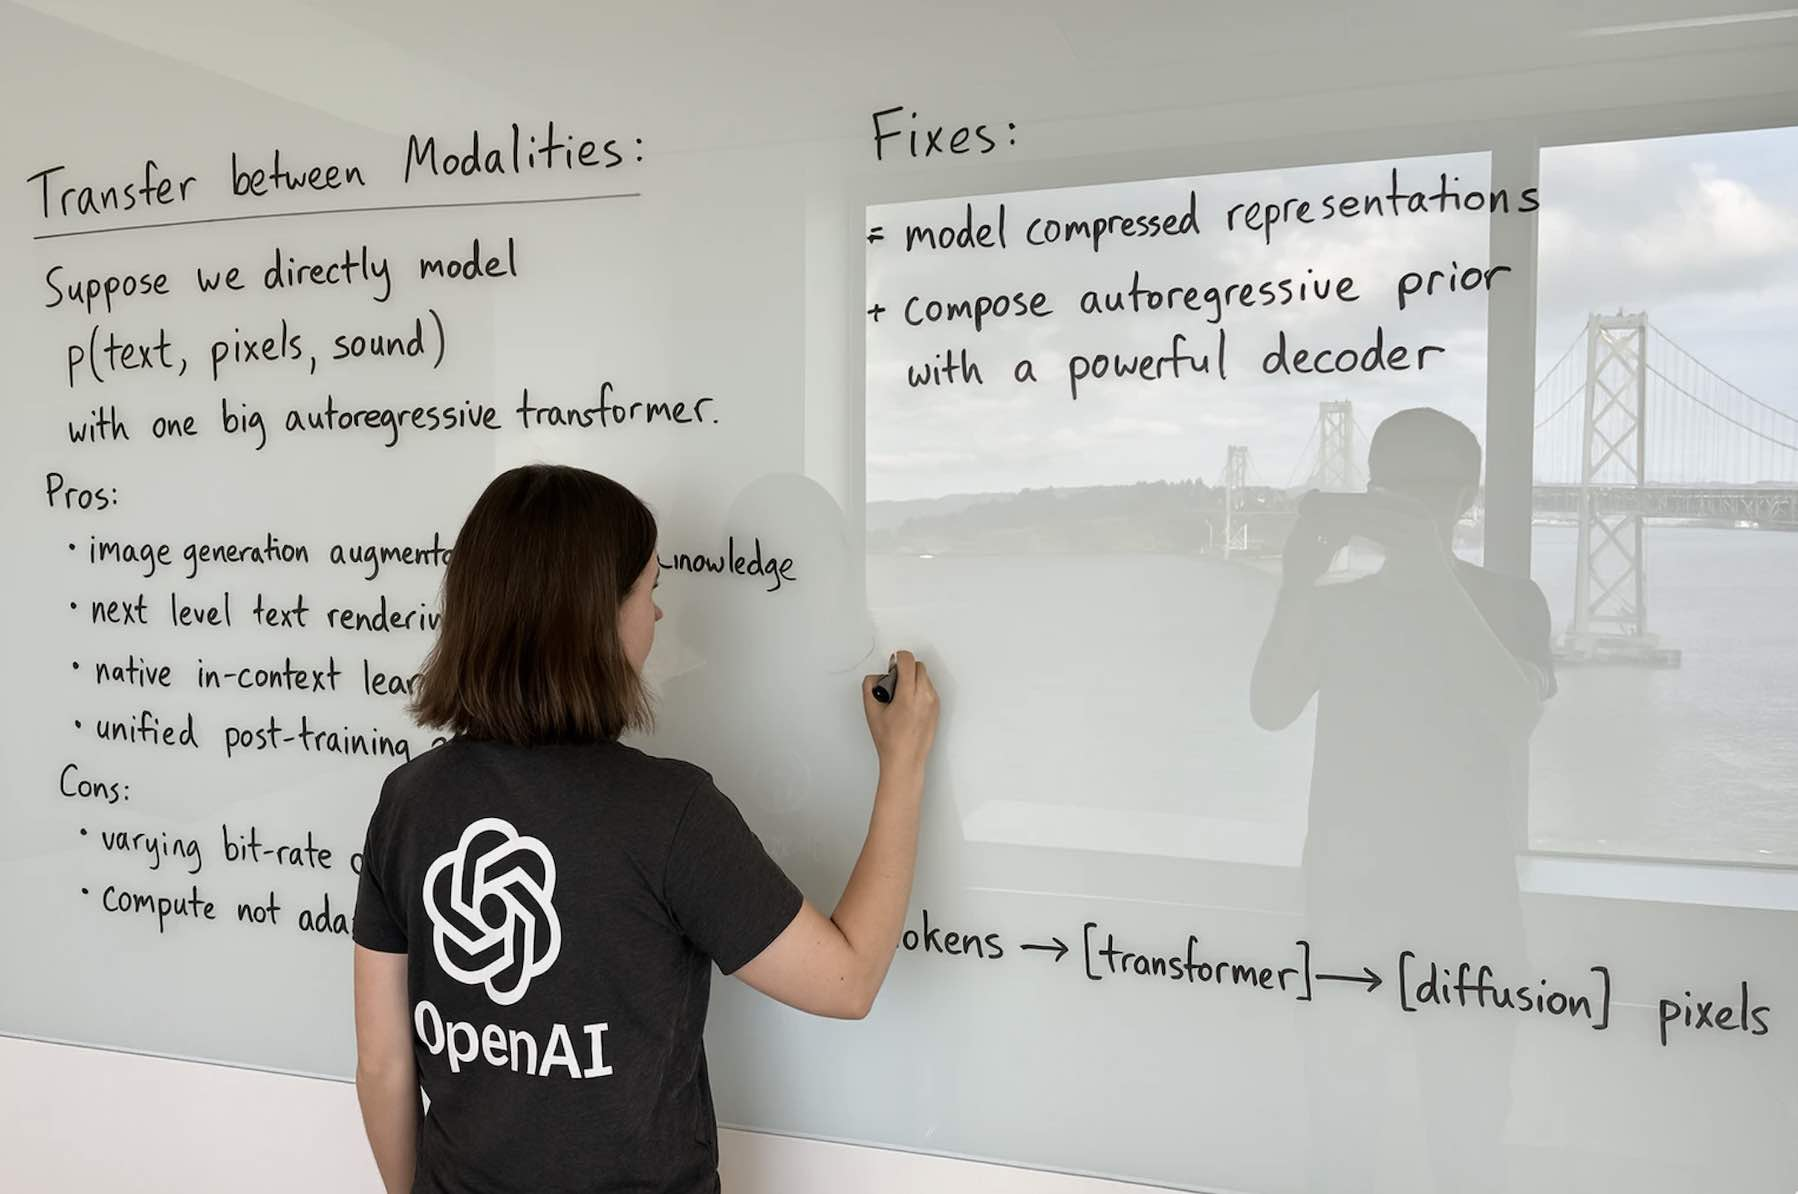

In [8]:
from IPython.display import Image, display
display(Image('../images/imagetotext1.jpg', width=600))

In [9]:
import os                                          # Access environment variables (e.g. os.getenv("API_KEY"))
import base64                                      # Encode local image files to base64 strings for API transmission
from dotenv import load_dotenv                     # Load API keys from a .env file into environment variables
from langchain_openai import ChatOpenAI            # LangChain wrapper used for OpenAI-compatible APIs (e.g. HuggingFace Router)
from langchain_core.messages import SystemMessage  # Sets the personality, role, and behavior of the AI before the conversation begins
from langchain_core.messages import HumanMessage   # Represents the user's input — the actual question, request, or prompt

load_dotenv('../keys/.env', override=True)
groq_api_key = os.getenv("GROQ_API_KEY")

# Must use a vision-capable model — llama-4-scout and llama-4-maverick support image input on Groq
model = ChatOpenAI(
    model       = "meta-llama/llama-4-scout-17b-16e-instruct",
    api_key     = groq_api_key,
    base_url    = "https://api.groq.com/openai/v1",
    temperature = 0.7,
    max_tokens  = 512
)

# Load your image as base64
with open("../images/imagetotext1.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")

# Build messages
messages = [
            SystemMessage(content="You are an expert image analyst. Describe images in great detail."),
            HumanMessage(content=[
                                    {"type": "text", "text": "Please describe this image in detail."},
                                    {"type"      : "image_url", "image_url" : {"url": f"data:image/jpeg;base64,{base64_image}"}}
                                ]
                        )
            ]

print("\n\033[1m=== Image Description ===\033[0m\n")
for chunk in model.stream(messages):
    print(chunk.content, end="", flush=True)


=== Image Description ===

The image depicts a woman writing on a whiteboard with a marker. The whiteboard is divided into two sections, each containing handwritten text in black marker.

**Left Section:**

*   **Title:** "Transfer between Modalities:"
*   **Text:** "Suppose we directly model p(text, pixels, sound) with one big autoregressive transformer."
*   **Pros:**
    *   Image generation augmenta
    *   Next level text renderiv
    *   Native in-context learn
    *   Unified post-training 
*   **Cons:**
    *   Varying bit-rate 
    *   Compute not ada

**Right Section:**

*   **Title:** "Fixes:"
*   **Text:** "= model compressed representations + compose autoregressive prior with a powerful decoder"

**Additional Elements:**

*   The woman has brown hair and wears a black t-shirt featuring the OpenAI logo.
*   A reflection of a man taking a photo of himself is visible on the right side of the whiteboard.
*   In the background, a bridge over water can be seen through a window.

## Example 6: Input Text and Generate an Image
- LangChain can support image generation through the ChatOpenAI integration using the OpenAI image_generation tool (via the Responses API). While the OpenAI platform historically used a separate /v1/images/generations endpoint, LangChain abstracts this by allowing chat models to call image generation tools.
- For simple image generation tasks, using the OpenAI SDK directly may still be simpler than integrating LangChain.
- Below is an example of using the opensource `stabilityai/sd-turbo model` to generate an image

/Users/arif/Documents/genai-course/.venv/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/arif/Documents/genai-course/.venv/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
Keyword arguments {'dtype': torch.float32} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/10 [00:00<?, ?it/s]

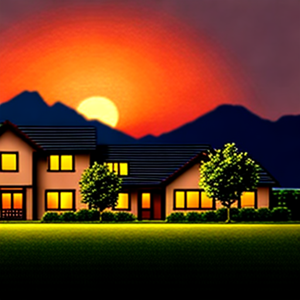

In [10]:
from diffusers import AutoPipelineForText2Image
from IPython.display import display  # to display the image in Jupyter Notebook
import torch             #  Import PyTorch deep learning framework for tensor operations and GPU acceleration
from PIL import Image

img_generator = AutoPipelineForText2Image.from_pretrained(
                                                        "stabilityai/sd-turbo",   # ~1.3GB, optimized for fast CPU/GPU inference
                                                        dtype=torch.float32 # safer for CPU (no float16 issues)
                                                        ).to("cpu")

prompt = "Create  an image of a house, with sun set in the back ground having trees and mountains"

# The pipeline returns a result object with a list of generated images. Since we only asked for one image, we grab the first (.images[0]).
image = img_generator(
        prompt=prompt, 
        num_inference_steps=10,  # controls how many denoising steps the diffusion model runs. More steps = better quality & more detail (but slower). On CPU, 20 is a reasonable tradeoff (default is usually 50).
        guidance_scale=7.5,      # controls how strongly the model follows your prompt. Higher values (e.g., 10–15) → stick closer to your words, but may reduce creativity. Lower values (e.g., 3–5) → more freedom, but less prompt adherence.
        height=512,              # reduce resolution for speed (default is 512x512)
        width=512
        )

# Display the image 
image_resized = image.images[0].resize((300, 300))
display(image_resized)

# <span style='background :lightgreen' >6. Hands-On Practice Examples </span>

In [11]:
import os                                          # Access environment variables (e.g. os.getenv("API_KEY"))
from dotenv import load_dotenv                     # Load API keys from a .env file into environment variables
from langchain_openai import ChatOpenAI            # LangChain wrapper for OpenAI-compatible APIs
from langchain_core.messages import SystemMessage  # Sets the personality, role, and behavior of the AI before the conversation begins
from langchain_core.messages import HumanMessage   # Represents the user's input — the actual question, request, or prompt

# Load API key from .env
load_dotenv("../keys/.env", override=True)

def ask_langchain(
    user_prompt:       str,
    system_prompt:     str   = "You are a helpful assistant that provides concise answers.",
    model_name:        str   = "gpt-4o-mini",
    api_key:           str   = os.environ["OPENAI_API_KEY"],   # Defaults to OpenAI key; override for other providers
    base_url:          str   = "https://api.openai.com/v1",    # Defaults to OpenAI; override for Groq, HuggingFace, etc.
    max_tokens:        int   = 1024,
    temperature:       float = 0.7,
    top_p:             float = 1.0,
    stream:            bool  = False,
):
    # Initialize the model with the given parameters
    model = ChatOpenAI(
                    model       = model_name,
                    api_key     = api_key,
                    base_url    = base_url,
                    max_tokens  = max_tokens,
                    temperature = temperature,
                    top_p       = top_p,
                    )

    # Prepare messages — same format for all providers
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    if stream:
        return model.stream(messages)    # Returns an iterator of AIMessageChunk objects — caller must loop over it
    
    response = model.invoke(messages)    # Returns a single AIMessage object
    return response.content              # Extract and return the text content

## a. Examples (Question Answering)

In [12]:
user_prompt = "Which is the capital of Pakistan?"
response = ask_langchain(user_prompt)
print(response)

The capital of Pakistan is Islamabad.


In [13]:
user_prompt = "Who is  Imran Khan"
response = ask_langchain(user_prompt, model_name="gpt-4.1-nano")
print(response)

Imran Khan is a Pakistani politician, former cricketer, and philanthropist. He served as the Prime Minister of Pakistan from 2018 to 2022 and is the founder and leader of the political party Pakistan Tehreek-e-Insaf (PTI).


## b. Question Answering from Content Passed

In [14]:
with open("../data/names.txt", "r") as f:
    file_content = f.read()

user_prompt = f"Can you extract names the Cricket players from this text:\n{file_content}"
response = ask_langchain(user_prompt=user_prompt)
print(response)

The cricket players mentioned in the text are:

1. Imran Khan
2. Wasim Akram
3. Shahid Afridi
4. Babar Azam
5. Shaheen Shah Afridi
6. Shadab Khan


## c. Examples (Binary Classification: Sentiment analysis, Spam detection, Medical diagnosis)

In [15]:
system_prompt = "You are an expert who will classify a sentense as having either a Positive or Negative sentiment."
user_prompt = "I love the youtube videos of Arif, as they are very informative"
response = ask_langchain(user_prompt=user_prompt, system_prompt=system_prompt, model_name="gpt-4.1-nano")
print(response)

Positive


## d. Examples (Multi-class Classification)

In [16]:
system_prompt = "Classify product reviews into these categories: 'Electronics', 'Clothing', 'Books', 'Home & Garden', 'Sports', or 'Food'. Respond with only the category."
user_prompt = "This novel has an incredible plot twist that kept me reading all night"
response = ask_langchain(user_prompt=user_prompt, system_prompt=system_prompt)
print(response)

Books


## e. Examples (Text Generation)

In [17]:
system_prompt = "You are an expert of political science and history and have a deep understanding of policical situation of Pakistan."
user_prompt = "Write down a 50 words summary about the fairness of general elections held in Pakistan on February 08, 2024."
response = ask_langchain(user_prompt=user_prompt, system_prompt=system_prompt, temperature=1.5)
print(response)

The general elections held in Pakistan on February 8, 2024, faced scrutiny concerning their fairness. Allegations of voter suppression, irregularities, and a lack of transparency marred the electoral process. International observers reported concerns over the impartiality of institutions, prompting debates about democratic integrity and the electoral legitimacy within the polarized political landscape.


## f. Examples (Code Generation)

In [18]:
system_prompt = "You are an expert of C programing in C language."
user_prompt = "Write down a C program that generates first ten numbers of fibonacci sequence."

response = ask_langchain(user_prompt=user_prompt, system_prompt=system_prompt, stream=True)

for chunk in response:  
    print(chunk.content, end="", flush=True) 

Sure! Below is a simple C program that generates the first ten numbers of the Fibonacci sequence.

```c
#include <stdio.h>

int main() {
    int n = 10; // Number of Fibonacci numbers to generate
    int fib[n]; // Array to hold the Fibonacci numbers

    // First two Fibonacci numbers
    fib[0] = 0;
    fib[1] = 1;

    // Generate Fibonacci numbers
    for (int i = 2; i < n; i++) {
        fib[i] = fib[i - 1] + fib[i - 2];
    }

    // Print the Fibonacci numbers
    printf("The first %d numbers of the Fibonacci sequence are:\n", n);
    for (int i = 0; i < n; i++) {
        printf("%d ", fib[i]);
    }
    printf("\n");

    return 0;
}
```

### Explanation:
1. We define an array `fib` to hold the Fibonacci numbers.
2. The first two Fibonacci numbers, `0` and `1`, are initialized.
3. A loop is used to calculate the next Fibonacci numbers by summing the two preceding numbers in the sequence.
4. Finally, we print the first ten Fibonacci numbers.

### How to Compile and Run:
1. Save 

## g. Examples (Text Translation)

In [19]:
system_prompt = "Please act as an expert of English to Urdu translator by translating the prompt from English into Urdu."
user_prompt = "The budget this year will have a very bad impact on the low salried people"
response = ask_langchain(user_prompt=user_prompt, system_prompt=system_prompt)
print(response)

اس سال کا بجٹ کم تنخواہ والے لوگوں پر بہت برا اثر ڈالے گا۔


## h. Examples (Text Summarization)

In [20]:
bio_text = """
Dr. Muhammad Arif Butt is an accomplished Assistant Professor at the  Department of Data Science, University of the Punjab (PU), Lahore, Pakistan. 
He holds an MSc and MPhil (both with Gold Medals) and a Ph.D. in Computer Science from PUCIT, University of the Punjab. His research focuses on fuzzy 
inference models applied to operating systems, embedded systems, and  cloud-based services, particularly in decision-making under uncertain and 
imprecise conditions. With over 33 years of experience in teaching and  management, Dr. Butt has served in both the Pakistan Army and University 
of the Punjab, bringing a wealth of interdisciplinary expertise. His teaching specializations include embedded and real-time operating systems, system programming, 
cybersecurity, and artificial intelligence. Beyond academia, he is a technology entrepreneur, serving as the Founder of Excaliat and Falcon-Hunt and Co-Founder of Tbox Solutionz. 
In recent years, he has gained significant expertise in vulnerability research, binary exploitation, and exploit development, excelling in identifying and mitigating critical security risks 
across diverse platforms. His deep understanding of software architectures, memory corruption techniques, and attack vectors strengthens his ability to proactively enhance cybersecurity defences. 
A dedicated and results-driven professional, Dr. Butt is recognized for his strong organizational skills, strategic thinking, and ability to thrive in collaborative environments. 
His expertise in cybersecurity and emerging technologies enables him to contribute effectively to both academic research and industry innovation, reinforcing defences against evolving cyber threats.
"""

user_prompt = f"Summarize the text below in at most 50 words:\n\n{bio_text}"
system_prompt = "You are an expert of English language."
response = ask_langchain(user_prompt=user_prompt, system_prompt=system_prompt, temperature=1.0)
print(response)

Dr. Muhammad Arif Butt is an accomplished Assistant Professor at the University of the Punjab, specializing in fuzzy inference models and cybersecurity. With over 33 years of experience, he is a technology entrepreneur and expert in vulnerability research, enhancing defenses against cyber threats through academic and industry contributions.


## i. Examples (Named Entity Recognition)

In [21]:
system_prompt = """You are a  Named Entity Recognition specialist. Extract and classify entities from the given text into these categories only if they exist:
- name
- major
- university
- nationality
- grades
- club
Format your response as: 'Entity: [text] | Type: [category]' with each entity on a new line."""

user_prompt = '''
Zelaid Mujahid is a sophomore majoring in Data Science at University of the Punjab. \
He is Pakistani national and has a 3.5 GPA. Mujahid is an active member of the department's AI Club.\
He hopes to pursue a career in AI after graduating.
'''
response = ask_langchain(user_prompt=user_prompt, system_prompt=system_prompt)
print(response)

Entity: Zelaid Mujahid | Type: name  
Entity: Data Science | Type: major  
Entity: University of the Punjab | Type: university  
Entity: Pakistani | Type: nationality  
Entity: 3.5 GPA | Type: grades  
Entity: AI Club | Type: club  


# <span style='background :lightgreen' >7. Accessing Closed/Open Source Embedding Models </span>
## Closed and Open Source Embedding Models

| Provider | Model | Type | Best For | Dimensions |
|----------|-------|------|----------|------------|
| **OpenAI** | text-embedding-3-small | Cloud | High quality, cost-effective | 1536 |
| **OpenAI** | text-embedding-3-large | Cloud | Highest quality | 3072 |
| **OpenAI** | text-embedding-ada-002 | Cloud | Legacy, stable | 1536 |
| **Google** | models/embedding-001 | Cloud | Multilingual support | 768 |
| **Google** | textembedding-gecko | Cloud | Text understanding | 768 |
| **Cohere** | embed-english-v3.0 | Cloud | English text | 1024 |
| **Cohere** | embed-multilingual-v3.0 | Cloud | Multilingual | 1024 |
| **Azure OpenAI** | text-embedding-ada-002 | Cloud | Enterprise OpenAI | 1536 |
| **HuggingFace** | all-MiniLM-L6-v2 | Local | Fast, lightweight | 384 |
| **HuggingFace** | all-mpnet-base-v2 | Local | High quality | 768 |
| **HuggingFace** | multi-qa-MiniLM-L6-cos-v1 | Local | Question-answering | 384 |
| **HuggingFace** | paraphrase-multilingual-MiniLM-L12-v2 | Local | Multilingual | 384 |
| **Ollama** | nomic-embed-text | Local | Privacy-focused | 768 |
| **Ollama** | mxbai-embed-large | Local | Large context | 1024 |
| **Sentence Transformers** | Custom models | Local | Domain-specific | Varies |
| **Bedrock** | amazon.titan-embed-text-v1 | Cloud | AWS ecosystem | 1536 |
| **Vertex AI** | textembedding-gecko | Cloud | Google Cloud | 768 |
| **Jina** | jina-embeddings-v2-base-en | Cloud/Local | Code & text | 768 |


## Example 1: Accessing Closed Source Embedding Models

In [22]:
import os                                 
from dotenv import load_dotenv   
import numpy as np               
from langchain_openai import OpenAIEmbeddings  # LangChain wrapper around OpenAI's Embeddings API — converts text into numerical vectors (embeddings)

load_dotenv('../keys/.env', override=True)  
openai_api_key = os.getenv("OPENAI_API_KEY")

# Step 1: Initialize the OpenAI Embedding Model (Closed Source)
openai_embedder = OpenAIEmbeddings(
                                model      = "text-embedding-3-small",  # "text-embedding-3-small" → 1536,  # "text-embedding-3-large" → higher quality, base dimensionality is 3072
                                api_key    = openai_api_key,            # Passes the OpenAI API key explicitly — needed since LangChain doesn't auto-read it here
                                dimensions = 100,                       # Truncates the output vector to 100 dimensions = less memory, faster similarity search, lower cost
                                )

# Step 2: Define Example Knowledge Base
doc1 = "Islamabad is the capital of Pakistan"  
doc2 = "Paris is the capital of France"        
doc3 = "Rome is the capital of Italy"          
documents = [doc1, doc2, doc3]  # Collect all documents into a list — this represents our mini knowledge base. In real RAG systems, this would be chunks from PDFs, websites, databases, etc.

# Step 3: Generate Embeddings for All Documents
doc_embeddings = openai_embedder.embed_documents(documents)  # embeds a LIST of strings in one API call and returns a list of vectors e.g. [[0.12, -0.34, ...], [0.56, 0.78, ...], [...]]
                                                             
# Step 4: Generate Embedding for the Query
query = "What is the capital of Pakistan?"           # The user's question — this is what we want to find the best match for
query_embedding = openai_embedder.embed_query(query) # .embed_query() → embeds a SINGLE string and returns ONE vector e.g., [0.23, -0.11, 0.45, ...]

# Step 5: Compute Cosine Similarity
def cosine_similarity(a, b):
    # Cosine similarity measures the ANGLE between two vectors, not their magnitude
    # Range: -1 (opposite) to 0 (unrelated) to 1 (identical meaning)
    # Formula: cos(θ) = (A · B) / (|A| × |B|)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

similarities = []                                    # Empty list to collect similarity scores for each document
for i, doc_emb in enumerate(doc_embeddings):          # Loop over each document embedding with its index. enumerate() gives (index, value) pairs: (0, emb1), (1, emb2), (2, emb3)
    sim = cosine_similarity(query_embedding, doc_emb) # Compute similarity between the query vector and this document's vector. Higher score = more semantically similar to the query
    similarities.append(sim)                          # Add this document's similarity score to the list
    print(f"Similarity with document {i+1}: {sim:.4f}")  # Print score — i+1 because humans count from 1 not 0. :.4f formats the float to 4 decimal places e.g. 0.8923

# Step 6: Find Most Similar Document
best_index = int(np.argmax(similarities))  # np.argmax() returns the INDEX of the highest value in the list
                                           # e.g. if similarities = [0.91, 0.23, 0.15] → returns 0 (index of 0.91)
                                           # int() converts numpy int to plain Python int (avoids type issues downstream)
best_doc = documents[best_index]           # Use the best index to retrieve the actual document text from the list

# Step 7: Show the Result
print("\033[1m=== Query ===\033[0m")         # \033[1m → ANSI escape code for bold text      \033[0m → resets formatting back to normal after the bold section
print(query)                   
print("\n\033[1m=== Most Similar Document ===\033[0m")  
print(best_doc)                                         
print(f"\n\033[1m(Similarity Score: {similarities[best_index]:.4f})\033[0m")  

Similarity with document 1: 0.7476
Similarity with document 2: 0.2197
Similarity with document 3: 0.1632
=== Query ===
What is the capital of Pakistan?

=== Most Similar Document ===
Islamabad is the capital of Pakistan

(Similarity Score: 0.7476)


## Example 2: Accessing Open Source Embedding Models

In [23]:
import numpy as np
from langchain_huggingface import HuggingFaceEmbeddings

#  Step 1: Initialize the Local Embedding Model
local_embedder = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

#  Step 2: Define Example Knowledge Base
doc1 = "Islamabad is the capital of Pakistan"
doc2 = "Paris is the capital of France"
doc3 = "Rome is the capital of Italy"
documents = [doc1, doc2, doc3]

#  Step 3: Generate Embeddings for All Documents
doc_embeddings = local_embedder.embed_documents(documents)

#  Step 4: Generate Embedding for the Query
query = "What is the capital of Pakistan?"
query_embedding = local_embedder.embed_query(query)


#  Step 5: Compute Cosine Similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

similarities = []
for i, doc_emb in enumerate(doc_embeddings):
    sim = cosine_similarity(query_embedding, doc_emb)
    similarities.append(sim)
    print(f"Similarity with document {i+1}: {sim:.4f}")

#  Step 6: Find Most Similar Document
best_index = int(np.argmax(similarities))
best_doc = documents[best_index]

#  Step 7: Show the Result
print("\033[1m=== Query ===\033[0m")
print(query)
print("\n\033[1m=== Most Similar Document ===\033[0m")
print(best_doc)
print(f"\n\033[1m(Similarity Score: {similarities[best_index]:.4f})\033[0m")

Similarity with document 1: 0.8102
Similarity with document 2: 0.2054
Similarity with document 3: 0.3416
=== Query ===
What is the capital of Pakistan?

=== Most Similar Document ===
Islamabad is the capital of Pakistan

(Similarity Score: 0.8102)
